<a href="https://colab.research.google.com/github/Fachreza28/pba-task-1a-individual/blob/main/Week4_TFIDF_MYBCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 4 TFIDF MYBCA

In [1]:
!pip install -U nltk
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.2 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


In [2]:
import pandas as pd
import numpy as np
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from timeit import default_timer as timer
import matplotlib.pyplot as plt

In [3]:
#### Load CSV dari local / upload
from google.colab import files
uploaded = files.upload()  # upload CSV dari local

import io
for fn in uploaded.keys():
    df_mybcarev = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f"File '{fn}' berhasil dimuat. Shape: {df_mybcarev.shape}")

Saving df_mybcarev_after_stopwords_sentiment_rating2.csv to df_mybcarev_after_stopwords_sentiment_rating2.csv
File 'df_mybcarev_after_stopwords_sentiment_rating2.csv' berhasil dimuat. Shape: (512156, 7)


In [4]:
#### Preview dataset
df_mybcarev.head()

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating,spelled_correction,tweet_without_stopwords
0,ok,5,0.5,0.5,Positive,ok,ok
1,susa amat buat qris di cek internet bagus dico...,1,0.0,0.0,Negative,susa amat buat qris di cek internet bagus dico...,susa qris cek internet bagus dicoba buka apk b...
2,ter indah tiasa 2 nya,5,0.0,0.0,Positive,ter indah tiasa 2 nya,ter indah tiasa 2
3,dengan bca mobile transaksi lebih mudah ga pak...,5,0.0,0.0,Positive,dengan bca mobile transaksi lebih mudah tidak ...,bca mobile transaksi mudah pake ngantridulu bc...
4,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,5,0.0,0.0,Positive,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,bca mobile ok🙏🙏👍🤣🤣


In [5]:
df_mybcarev[['tweet_without_stopwords', 'sentiment_rating']].value_counts('sentiment_rating')

,count
sentiment_rating,
Positive,369027
Negative,113310
Neutral,29819


In [6]:
#### LIMIT 50.000 data (stratified agar distribusi label tetap seimbang)
SAMPLE_SIZE = 50000

df = df_mybcarev[['tweet_without_stopwords', 'sentiment_rating']].dropna().reset_index(drop=True)

if len(df) > SAMPLE_SIZE:
    df = df.groupby('sentiment_rating', group_keys=False).apply(
        lambda x: x.sample(frac=SAMPLE_SIZE / len(df), random_state=42)
    ).reset_index(drop=True)

print(f"Jumlah data yang digunakan: {len(df)}")
print(df['sentiment_rating'].value_counts())

Jumlah data yang digunakan: 50000
sentiment_rating
Positive    35792
Negative    11278
Neutral      2930
Name: count, dtype: int64


/tmp/ipykernel_2947/174869873.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('sentiment_rating', group_keys=False).apply(


In [7]:
#### Encode label: Negative=0, Positive=1
label_encode = LabelEncoder()
Y = label_encode.fit_transform(df['sentiment_rating'])
print("Kelas:", label_encode.classes_)  # pastikan urutan [Negative, Positive]
print("0 =", label_encode.classes_[0], "| 1 =", label_encode.classes_[1])

Kelas: ['Negative' 'Neutral' 'Positive']
0 = Negative | 1 = Neutral


In [8]:
x = df['tweet_without_stopwords'].astype(str)

In [9]:
#### Split dataset 80/20
xtrain, xtest, ytrain, ytest = train_test_split(x, Y, test_size=0.2, random_state=42, stratify=Y)
print(f"Training set : {len(xtrain)} data")
print(f"Testing set  : {len(xtest)} data")

Training set : 40000 data
Testing set  : 10000 data


In [10]:
#### TF-IDF Vectorization
#### FIX: fit sekali di seluruh training data, baru transform

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

start = timer()
# fit SEKALI di seluruh training data
X_train_tfidf = tfidf_vectorizer.fit_transform(xtrain)   # sparse matrix, hemat memory
X_test_tfidf  = tfidf_vectorizer.transform(xtest)        # pakai vocabulary yang sama
print(f"TF-IDF selesai dalam {timer() - start:.2f} detik")
print(f"Shape train: {X_train_tfidf.shape} | Shape test: {X_test_tfidf.shape}")

TF-IDF selesai dalam 0.39 detik
Shape train: (40000, 5000) | Shape test: (10000, 5000)


In [11]:
#### Fungsi evaluasi model
def evaluate_model(model, X_test, y_test):
    y_pred    = model.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    report    = classification_report(y_test, y_pred)
    cm        = confusion_matrix(y_test, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [12]:
#### Initialize classifiers
svm_classifier = LinearSVC(dual='auto')
logistic_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier(
    n_estimators=100,
    tree_method='hist',   # lebih cepat dan hemat memory vs default
    random_state=42
)
random_forest_classifier = RandomForestClassifier(
    n_estimators=100, max_depth=3, max_features='sqrt',
    min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=0
)

In [14]:
# Cek dulu kelas yang ada di data kamu
print(df['sentiment_rating'].value_counts())

sentiment_rating
Positive    35792
Negative    11278
Neutral      2930
Name: count, dtype: int64


In [15]:
def evaluate_model(model, X_test, y_test):
    y_pred    = model.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    report    = classification_report(y_test, y_pred, zero_division=0)
    cm        = confusion_matrix(y_test, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [16]:
## Linear SVM
start = timer()
svm_tfidf = svm_classifier.fit(X_train_tfidf, ytrain)
print(f'Training Linear SVM selesai dalam {timer() - start:.2f} detik')

start = timer()
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, cm_svm = evaluate_model(svm_tfidf, X_test_tfidf, ytest)
print(f'Prediksi Linear SVM selesai dalam {timer() - start:.2f} detik')

print(f"\nLinear SVM Accuracy : {accuracy_svm:.2f}")
print(f"Linear SVM Precision: {precision_svm:.2f}")
print(f"Linear SVM Recall   : {recall_svm:.2f}")
print(f"Linear SVM F1 Score : {f1_svm:.2f}")
print("Classification Report:\n", report_svm)
print("Confusion Matrix:\n", cm_svm)

Training Linear SVM selesai dalam 5.63 detik
Prediksi Linear SVM selesai dalam 0.04 detik

Linear SVM Accuracy : 0.84
Linear SVM Precision: 0.81
Linear SVM Recall   : 0.84
Linear SVM F1 Score : 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.76      0.72      2256
           1       0.12      0.02      0.04       586
           2       0.90      0.93      0.92      7158

    accuracy                           0.84     10000
   macro avg       0.57      0.57      0.56     10000
weighted avg       0.81      0.84      0.82     10000

Confusion Matrix:
 [[1715   53  488]
 [ 315   12  259]
 [ 452   32 6674]]


In [17]:
## Logistic Regression
start = timer()
lr_tfidf = logistic_regression.fit(X_train_tfidf, ytrain)
print(f'Training Logistic Regression selesai dalam {timer() - start:.2f} detik')

start = timer()
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = evaluate_model(lr_tfidf, X_test_tfidf, ytest)
print(f'Prediksi Logistic Regression selesai dalam {timer() - start:.2f} detik')

print(f"\nLogistic Regression Accuracy : {accuracy_lr:.2f}")
print(f"Logistic Regression Precision: {precision_lr:.2f}")
print(f"Logistic Regression Recall   : {recall_lr:.2f}")
print(f"Logistic Regression F1 Score : {f1_lr:.2f}")
print("Classification Report:\n", report_lr)
print("Confusion Matrix:\n", cm_lr)

Training Logistic Regression selesai dalam 3.66 detik
Prediksi Logistic Regression selesai dalam 0.03 detik

Logistic Regression Accuracy : 0.85
Logistic Regression Precision: 0.81
Logistic Regression Recall   : 0.85
Logistic Regression F1 Score : 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.78      0.74      2256
           1       0.11      0.01      0.01       586
           2       0.90      0.94      0.92      7158

    accuracy                           0.85     10000
   macro avg       0.57      0.57      0.56     10000
weighted avg       0.81      0.85      0.82     10000

Confusion Matrix:
 [[1754   18  484]
 [ 321    4  261]
 [ 439   14 6705]]


In [18]:
## Naive Bayes
start = timer()
nb_tfidf = nb_classifier.fit(X_train_tfidf, ytrain)
print(f'Training Naive Bayes selesai dalam {timer() - start:.2f} detik')

start = timer()
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_tfidf, X_test_tfidf, ytest)
print(f'Prediksi Naive Bayes selesai dalam {timer() - start:.2f} detik')

print(f"\nNaive Bayes Accuracy : {accuracy_nb:.2f}")
print(f"Naive Bayes Precision: {precision_nb:.2f}")
print(f"Naive Bayes Recall   : {recall_nb:.2f}")
print(f"Naive Bayes F1 Score : {f1_nb:.2f}")
print("Classification Report:\n", report_nb)
print("Confusion Matrix:\n", cm_nb)

Training Naive Bayes selesai dalam 0.01 detik
Prediksi Naive Bayes selesai dalam 0.02 detik

Naive Bayes Accuracy : 0.85
Naive Bayes Precision: 0.81
Naive Bayes Recall   : 0.85
Naive Bayes F1 Score : 0.83
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.85      0.75      2256
           1       0.00      0.00      0.00       586
           2       0.92      0.92      0.92      7158

    accuracy                           0.85     10000
   macro avg       0.53      0.59      0.56     10000
weighted avg       0.81      0.85      0.83     10000

Confusion Matrix:
 [[1914    1  341]
 [ 381    0  205]
 [ 577    0 6581]]


In [19]:
## XGBoost
## Catatan: XGBoost menerima sparse matrix langsung, tidak perlu .toarray()
start = timer()
xgboost_tfidf = xgboost_classifier.fit(X_train_tfidf, ytrain)
print(f'Training XGBoost selesai dalam {timer() - start:.2f} detik')

start = timer()
y_pred_xgb, accuracy_xgboost, precision_xgb, recall_xgb, f1_xgb, report_xgb, cm_xgb = evaluate_model(xgboost_tfidf, X_test_tfidf, ytest)
print(f'Prediksi XGBoost selesai dalam {timer() - start:.2f} detik')

print(f"\nXGBoost Accuracy : {accuracy_xgboost:.2f}")
print(f"XGBoost Precision: {precision_xgb:.2f}")
print(f"XGBoost Recall   : {recall_xgb:.2f}")
print(f"XGBoost F1 Score : {f1_xgb:.2f}")
print("Classification Report:\n", report_xgb)
print("Confusion Matrix:\n", cm_xgb)

Training XGBoost selesai dalam 23.04 detik
Prediksi XGBoost selesai dalam 0.11 detik

XGBoost Accuracy : 0.83
XGBoost Precision: 0.80
XGBoost Recall   : 0.83
XGBoost F1 Score : 0.81
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.69      0.69      2256
           1       0.19      0.02      0.04       586
           2       0.88      0.94      0.91      7158

    accuracy                           0.83     10000
   macro avg       0.59      0.55      0.55     10000
weighted avg       0.80      0.83      0.81     10000

Confusion Matrix:
 [[1560   24  672]
 [ 294   12  280]
 [ 381   27 6750]]


In [20]:
## Random Forest
## Random Forest butuh dense array — convert di sini saja (bukan di awal)
## Dengan 50rb data dan max_features='sqrt', ini masih aman
start = timer()
rfc_tfidf = random_forest_classifier.fit(X_train_tfidf, ytrain)
print(f'Training Random Forest selesai dalam {timer() - start:.2f} detik')

start = timer()
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = evaluate_model(rfc_tfidf, X_test_tfidf, ytest)
print(f'Prediksi Random Forest selesai dalam {timer() - start:.2f} detik')

print(f"\nRandom Forest Accuracy : {accuracy_rfc:.2f}")
print(f"Random Forest Precision: {precision_rfc:.2f}")
print(f"Random Forest Recall   : {recall_rfc:.2f}")
print(f"Random Forest F1 Score : {f1_rfc:.2f}")
print("Classification Report:\n", report_rfc)
print("Confusion Matrix:\n", cm_rfc)

Training Random Forest selesai dalam 0.57 detik
Prediksi Random Forest selesai dalam 0.07 detik

Random Forest Accuracy : 0.72
Random Forest Precision: 0.51
Random Forest Recall   : 0.72
Random Forest F1 Score : 0.60
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      2256
           1       0.00      0.00      0.00       586
           2       0.72      1.00      0.83      7158

    accuracy                           0.72     10000
   macro avg       0.24      0.33      0.28     10000
weighted avg       0.51      0.72      0.60     10000

Confusion Matrix:
 [[   0    0 2256]
 [   0    0  586]
 [   0    0 7158]]


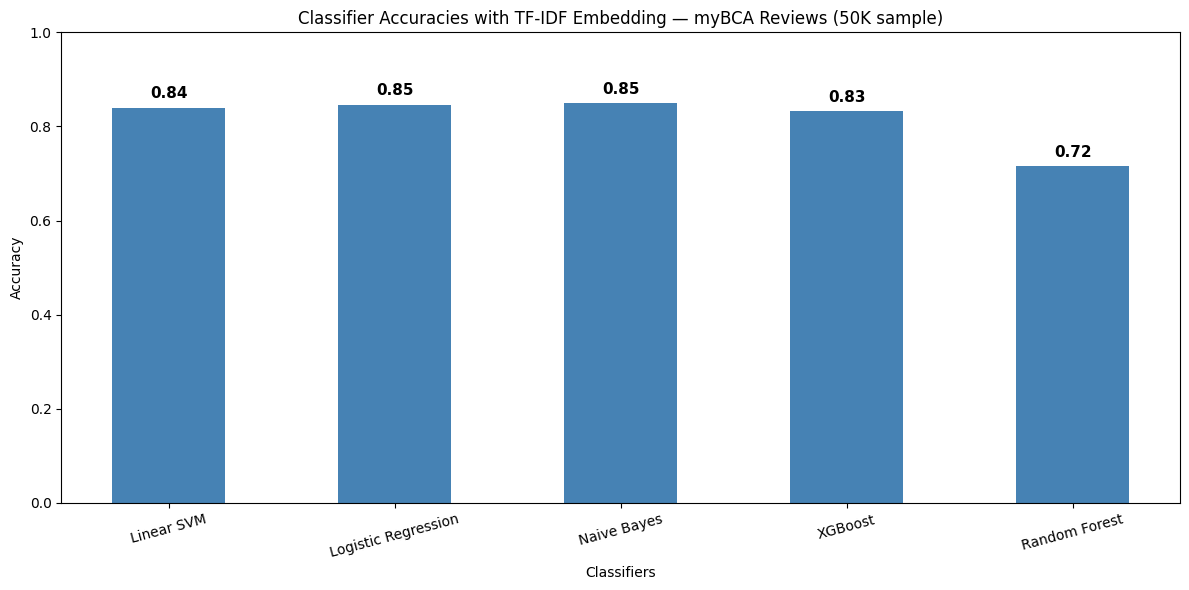

In [21]:
#### Visualisasi Perbandingan Akurasi semua Classifier
classifiers = ["Linear SVM", "Logistic Regression", "Naive Bayes", "XGBoost", "Random Forest"]
tfidf_accuracies = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

x_pos = np.arange(len(classifiers))

plt.figure(figsize=(12, 6))
bars = plt.bar(x_pos, tfidf_accuracies, width=0.5, color='steelblue')

plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with TF-IDF Embedding — myBCA Reviews (50K sample)')
plt.xticks(x_pos, classifiers, rotation=15)
plt.ylim(0, 1.0)

for i, acc in enumerate(tfidf_accuracies):
    plt.text(x_pos[i], acc + 0.02, f"{acc:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
#### Ringkasan hasil semua classifier
summary_df = pd.DataFrame({
    'Classifier': classifiers,
    'Accuracy': tfidf_accuracies
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(summary_df.to_string(index=False))

         Classifier  Accuracy
        Naive Bayes    0.8495
Logistic Regression    0.8463
         Linear SVM    0.8401
            XGBoost    0.8322
      Random Forest    0.7158
